# Week 2 — Advanced Visualization & Data Storytelling
### Dataset / Domain: Titanic Passenger Survival

**Goal:** Build a data story for a **non-technical audience** (e.g. a museum curator, a journalist, or a
maritime-safety board) explaining *who* survived the Titanic disaster and *why* — using sophisticated,
well-chosen visualizations.

Run top-to-bottom in **Google Colab**.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install plotly --quiet
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

train_file = [f for f in uploaded if 'train' in f.lower()][0]
train = pd.read_csv(train_file)

test_files = [f for f in uploaded if 'test' in f.lower()]

if test_files:
    test = pd.read_csv(test_files[0])
else:
    test = None

print("Train:", train.shape)
print("Test:", test.shape if test is not None else "Not provided")
train.head()


Saving train.csv to train.csv
Saving test.csv to test.csv
Train: (891, 12)
Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Quick Re-Clean (carried over from Week 1)

In [3]:
# Minimal cleaning so the visuals below aren't distorted by missing/incorrect data
train['Has_Cabin'] = train['Cabin'].notnull().astype(int)
train['Age'] = train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Feature engineering for richer storytelling
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
train['Title'] = train['Name'].str.extract(r',\s*([^\.]*)\s*\.')
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
train['Title'] = train['Title'].replace(title_map)
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 80],
                             labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
train['SurvivedLabel'] = train['Survived'].map({0: 'Did not survive', 1: 'Survived'})
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,FamilySize,IsAlone,Title,AgeGroup,SurvivedLabel
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,Mr,Young Adult,Did not survive
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0,Mrs,Adult,Survived
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,Miss,Young Adult,Survived
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0,Mrs,Young Adult,Survived
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,Mr,Young Adult,Did not survive


## 3. The Story: "Who Lived, Who Died, and Why"

We'll build this narrative in five acts, each backed by a purpose-built chart:

1. **The scale of the tragedy** — how many people were on board vs. how many survived
2. **"Women and children first"** — the single biggest driver of survival
3. **Money bought a better chance** — class and fare effects
4. **Family size sweet spot** — traveling alone or in a large family was riskier
5. **Where you boarded mattered too** — embarkation port as a proxy for class mix


### Act 1 — The Scale of the Tragedy

In [4]:
# Chart 1: Donut chart of survival — simple, immediately readable by any audience
fig = px.pie(train, names='SurvivedLabel', hole=0.5,
             color='SurvivedLabel',
             color_discrete_map={'Survived': '#2ca02c', 'Did not survive': '#d62728'},
             title="Of 891 Passengers Aboard, Only ~38% Survived")
fig.update_traces(textinfo='percent+label')
fig.show()


**Why this chart:** A donut/pie chart is instantly intuitive for a non-technical audience —
it visually communicates a stark, single-number takeaway (most people died) without requiring
any statistical literacy.

### Act 2 — \"Women and Children First\"

In [5]:
# Chart 2: Diverging bar chart of survival rate by Sex and AgeGroup
rate_table = (train.groupby(['Sex', 'AgeGroup'], observed=True)['Survived']
              .mean().reset_index())

fig = px.bar(rate_table, x='AgeGroup', y='Survived', color='Sex', barmode='group',
             color_discrete_map={'male': '#4c72b0', 'female': '#dd8452'},
             title="Survival Rate by Age Group and Sex",
             labels={'Survived': 'Survival Rate'})
fig.update_layout(yaxis_tickformat='.0%')
fig.show()


**Why this chart:** A grouped bar chart lets the audience directly compare two categorical
dimensions (sex and age group) at once. The pattern jumps out immediately: women survived at far
higher rates than men in every age group, and children fared better than adult men — visually proving
the "women and children first" evacuation policy really happened.

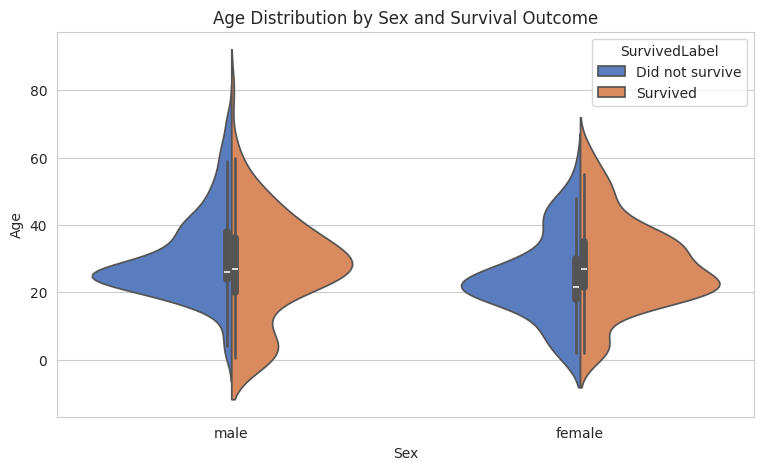

In [6]:
# Chart 3: Violin plot — Age distribution by survival, split by sex
plt.figure(figsize=(9, 5))
sns.violinplot(data=train, x='Sex', y='Age', hue='SurvivedLabel', split=True, palette='muted')
plt.title("Age Distribution by Sex and Survival Outcome")
plt.ylabel("Age")
plt.show()


**Why this chart:** A split violin plot shows the *full shape* of the age distribution (not just
an average), letting us see, for instance, that young boys had noticeably better survival odds than
adult men — a nuance a simple bar chart would hide.

### Act 3 — Money Bought a Better Chance

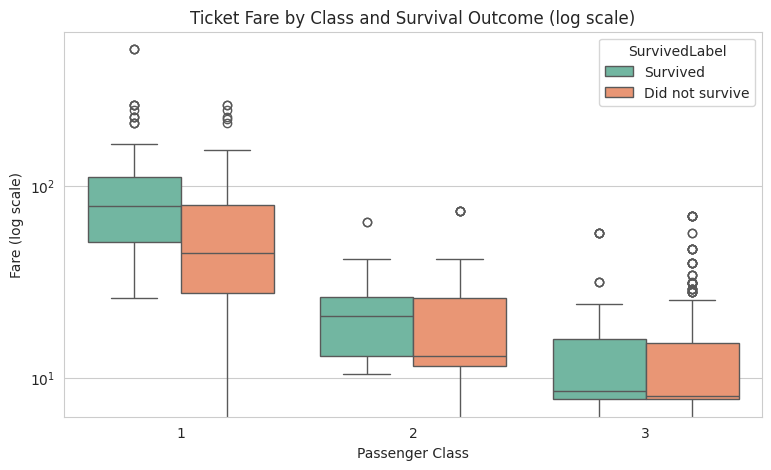

In [7]:
# Chart 4: Box plot of Fare by class and survival (log scale to handle skew)
plt.figure(figsize=(9, 5))
sns.boxplot(data=train, x='Pclass', y='Fare', hue='SurvivedLabel', palette='Set2')
plt.yscale('log')
plt.title("Ticket Fare by Class and Survival Outcome (log scale)")
plt.ylabel("Fare (log scale)")
plt.xlabel("Passenger Class")
plt.show()


**Why this chart:** Fare is heavily right-skewed (a few very expensive tickets), so a log-scaled
box plot avoids the distortion a linear axis would cause, while still clearly showing that survivors
within each class tended to have paid more — hinting at cabin location or priority boarding advantages
tied to wealth.

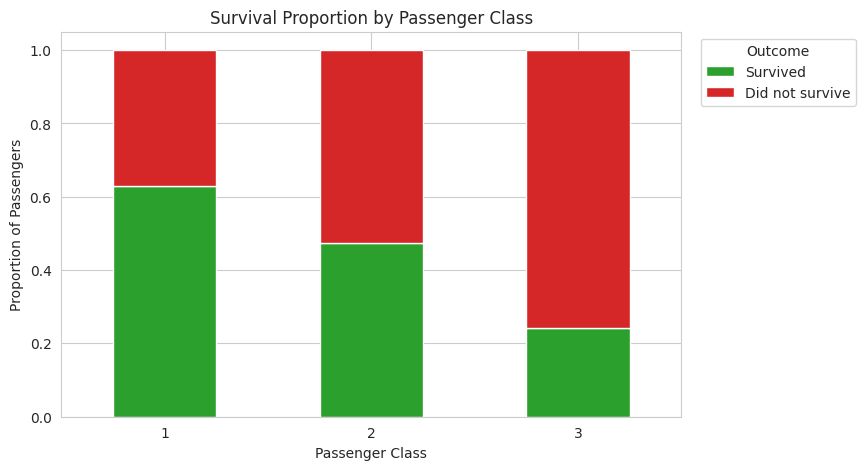

In [8]:
# Chart 5: Stacked/100% bar chart — survival proportion by class
prop = pd.crosstab(train['Pclass'], train['Survived'], normalize='index')
prop.columns = ['Did not survive', 'Survived']
prop = prop[['Survived', 'Did not survive']]

ax = prop.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(8, 5))
plt.title("Survival Proportion by Passenger Class")
plt.ylabel("Proportion of Passengers")
plt.xlabel("Passenger Class")
plt.xticks(rotation=0)
plt.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


**Why this chart:** A 100%-stacked bar chart is the clearest way to show *proportions* across
categories to a lay audience — it removes the distraction of raw counts (which differ a lot between
classes) and focuses attention purely on the survival rate gap: 1st class passengers were roughly
2.5x more likely to survive than 3rd class.

### Act 4 — The Family Size Sweet Spot

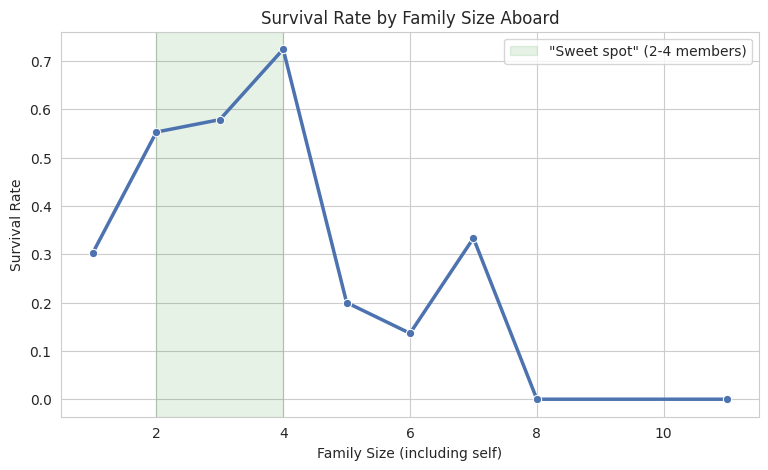

In [9]:
# Chart 6: Line chart of survival rate vs. family size
family_rate = train.groupby('FamilySize')['Survived'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=family_rate, x='FamilySize', y='Survived', marker='o', linewidth=2.5, color='#4c72b0')
plt.title("Survival Rate by Family Size Aboard")
plt.xlabel("Family Size (including self)")
plt.ylabel("Survival Rate")
plt.axvspan(2, 4, color='green', alpha=0.1, label='"Sweet spot" (2-4 members)')
plt.legend()
plt.show()


**Why this chart:** A line chart is ideal for showing a trend across an ordered numeric variable.
It reveals a non-obvious, "inverted-U" insight: passengers traveling completely alone *and* those in
very large families (6+) had lower survival odds than those in small families of 2-4 — a nuance a bar
chart of "alone vs not alone" would completely miss.

### Act 5 — Where You Boarded Mattered

In [10]:
# Chart 7: Sunburst chart — Embarked > Pclass > Survival
sun_df = train.copy()
sun_df['Outcome'] = sun_df['SurvivedLabel']
fig = px.sunburst(sun_df, path=['Embarked', 'Pclass', 'Outcome'],
                   title="Passenger Breakdown: Embarkation Port → Class → Outcome",
                   color='Outcome',
                   color_discrete_map={'Survived': '#2ca02c', 'Did not survive': '#d62728', '(?)': 'grey'})
fig.show()


**Why this chart:** A sunburst chart lets a non-technical audience explore a *hierarchical* story
in one glance — starting from the outer ring (embarkation port), drilling into class, and finally into
outcome. It shows, for example, that Southampton brought aboard the most 3rd-class passengers, which
partly explains why the port with the most boarders also had a lower overall survival rate.

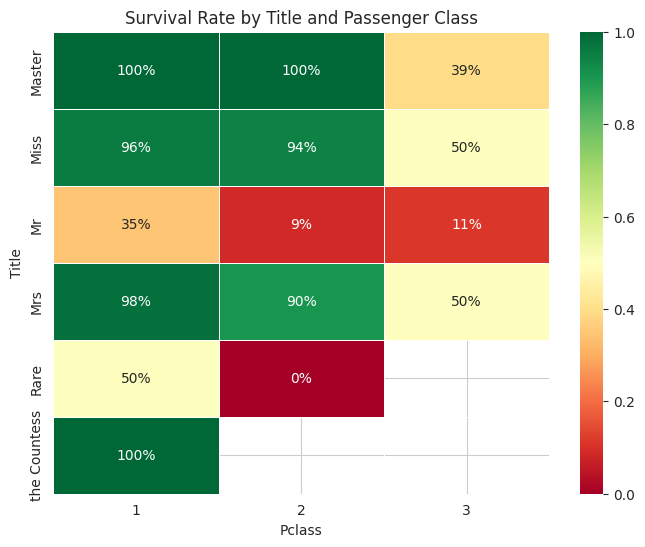

In [11]:
# Chart 8 (bonus): Heatmap of survival rate by Title and Pclass — a richer proxy for social status
pivot = train.pivot_table(index='Title', columns='Pclass', values='Survived', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap='RdYlGn', linewidths=0.5)
plt.title("Survival Rate by Title and Passenger Class")
plt.show()


**Why this chart:** `Title` (extracted from passenger names) captures social status more finely
than `Sex` alone (e.g. distinguishing "Master" — young boys — from "Mr"). A heatmap efficiently
compresses two categorical dimensions and a continuous rate into a single, color-coded grid that a
reader can scan for hot/cold spots at a glance.

## 4. The Story, Told Simply (for a non-technical reader)

> On the night of April 15, 1912, the Titanic carried 891 passengers in our sample. Only about 4 in 10
> survived. But survival was not random luck — it followed clear, visible rules.
>
> **If you were a woman or a child, you were far more likely to live.** Crew followed a strict
> "women and children first" policy, and the data shows it: survival rates for women were several times
> higher than for men, in every age bracket.
>
> **If you had money, you had a better chance.** First-class passengers survived at roughly 2.5x the
> rate of third-class passengers — likely due to cabin locations closer to lifeboats and preferential
> access during evacuation.
>
> **Family size mattered too** — travelling with a small family (2-4 people) offered the best odds,
> likely because groups could help each other reach lifeboats, while solo travelers had no one to help
> them and very large families struggled to stay together and evacuate as a unit.
>
> **Where you boarded hinted at your fate** — ports that brought aboard more third-class passengers saw
> lower overall survival, an early echo of the class effect above.

## 5. Business / Scientific Implications

- **Maritime safety regulation:** This tragedy directly influenced SOLAS (Safety of Life at Sea)
  regulations — mandating sufficient lifeboats for all passengers regardless of ticket class.
- **Equity in emergency protocols:** The clear class-based survival gap is a cautionary case study for
  any industry (aviation, event management, disaster response) — access to safety resources should not
  correlate with fare paid or seating tier.
- **Group dynamics in emergencies:** The family-size "sweet spot" finding has parallels in modern
  evacuation planning and crowd psychology research — neither isolated individuals nor oversized groups
  evacuate as efficiently as small, cohesive units.
- **For a data science / analytics team:** these patterns (sex, class, family size, title, embarkation)
  are exactly the engineered features that make Titanic survival highly predictable with machine
  learning — which we'll build in Week 4.
